In [ ]:
#ai vs human content detection
# it is supervised alssifcation ai or human
#is to learn the pattern of the
#tesx

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string

sns.set()





In [31]:
#load the dataset
data = pd.read_csv('/content/ai_human_detection_v1.csv')
#show first rows
data.head()

,id,text,human_or_ai,source_model,prompt,domain,language,edit_level,word_count,generation_date,version
0,e37e31c0-35d0-486d-9760-efadd4e0e289,Aprender programación en Python es fácil . Pri...,human,Human,NaN,Technical Blog,es,none,34,2026-01-29T08:38:18.272755,v1.0
1,68e294cf-a499-4fbf-8616-2d6324570be9,Error: 400 Client Error: Bad Request for url: ...,ai,gemma2-9b-it,Discute el papel de la tecnología en el aprend...,Education,es,none,9,2026-01-29T08:58:20.717225,v1.0
2,b5e06ef0-9758-471f-81dc-182c6117ee81,Error: 404 Client Error: Not Found for url: ht...,ai,gemma2-9b-itllama-3.3-70b-versatile,Create a cold outreach email for business part...,Email,en,none,9,2026-01-29T09:13:20.114765,v1.0
3,6177fc40-1567-445b-af15-f3250ddd3403,**Global Economic Trends: A Shifting Landscape...,ai,llama-3.1-8b-instant,Write about economic trends affecting global m...,News,en,none,558,2026-01-29T08:39:55.917663,v1.0
4,192a9615-ed51-4750-b649-d18f8882f555,"""Recuerda que tú eres fuerte, capaz y única. N...",ai,llama-3.1-8b-instant,Escribe una publicación inspiradora para redes...,Social Media,es,none,147,2026-01-29T08:42:52.451370,v1.0


In [32]:
#check missing data(prompt 0,684,685)
print(data.isna())


        id   text  human_or_ai  source_model  prompt  domain  language  \
0    False  False        False         False    True   False     False   
1    False  False        False         False   False   False     False   
2    False  False        False         False   False   False     False   
3    False  False        False         False   False   False     False   
4    False  False        False         False   False   False     False   
..     ...    ...          ...           ...     ...     ...       ...   
681  False  False        False         False   False   False     False   
682  False  False        False         False   False   False     False   
683  False  False        False         False   False   False     False   
684  False  False        False         False    True   False     False   
685  False  False        False         False    True   False     False   

     edit_level  word_count  generation_date  version  
0         False       False            False    False  

In [33]:
#count the missing values
print(data.isna().sum())


id                   0
text                 0
human_or_ai          0
source_model         0
prompt             181
domain               0
language             0
edit_level           0
word_count           0
generation_date      0
version              0
dtype: int64


In [34]:
#dublicate data
data.duplicated()[data.duplicated()==True]

,0


In [ ]:
#filtering the words not related
error_filter = data['text'].str.contains("Client Error", na=False)
#new dataset
data_clean = data[~error_filter].copy()

print(f"Original Rows: {len(data)}")
print(f"Cleaned Rows:  {len(data_clean)}")
print(f"Removed {len(data) - len(data_clean)} garbage rows.")

Original Rows: 686
Cleaned Rows:  680
Removed 6 garbage rows.


In [52]:
if len(class_counts) > 1:
    # Get the value at position 0 and position 1
    ratio = class_counts.iloc[0] / class_counts.iloc[1]
    print(f"Ratio (Majority/Minority): {ratio:.2f}")
else:
    print("Error: Only one class found!")

print(class_counts)

Ratio (Majority/Minority): 1.85
human_or_ai
ai                335
human             181
post_edited_ai    170
Name: count, dtype: int64


In [ ]:
#convert to binery
label_mapping = {
    'human': 0,
    'ai': 1,
    'post_edited_ai': 1
}
#add new coulment 
data_clean['target'] = data_clean['human_or_ai'].map(label_mapping)

In [ ]:
#if theres empty row fill with unknown
data_clean['prompt'] = data_clean['prompt'].fillna("Unknown")

In [56]:
# new data
print(data_clean['target'].value_counts())

target
1    499
0    181
Name: count, dtype: int64


In [ ]:
#count the number of ai and human 
counts = data_clean['target'].value_counts()
print(f"\nAI (1) count: {counts[1]}")
print(f"Human (0) count: {counts[0]}")
print(f"Imbalance Ratio: {counts[1] / counts[0]:.2f} to 1")


AI (1) count: 499
Human (0) count: 181
Imbalance Ratio: 2.76 to 1


In [61]:
#convert str time to obj
data_clean['generation_date'] = pd.to_datetime(data_clean['generation_date'], errors='coerce')

In [62]:
#sorting
data_sorted = data_clean.sort_values(by='generation_date')

In [92]:
def analyze_text_structure(text):
    if not isinstance(text, str): return pd.Series([0, 0, 0, 0, 0, 0])
    # 1 Word & Sentence Tokens
    words = text.split()
    sentences = text.replace('!', '.').replace('?', '.').split('.')
    sentences = [s for s in sentences if len(s) > 1] # ignore empty splits

    # 2 Length Features
    word_count = len(words)
    sentence_count = len(sentences)
    avg_word_len = np.mean([len(w) for w in words]) if word_count > 0 else 0
    avg_sentence_len = word_count / sentence_count if sentence_count > 0 else 0

    # 3 Diversity Feature (Unique words / Total words)
    lexical_diversity = len(set(words)) / word_count if word_count > 0 else 0

    # 4 Puncuation Load
    punct_count = sum([1 for char in text if char in string.punctuation])

    return pd.Series([word_count, avg_word_len, sentence_count, avg_sentence_len, lexical_diversity, punct_count])

In [93]:
# new columns
features = ['word_count', 'avg_word_length', 'sentence_count', 'avg_sentence_length', 'lexical_diversity', 'punctuation_count']
data_sorted[features] = data_sorted['text'].apply(analyze_text_structure)

print("Feature Engineering Complete. New columns added.")

Feature Engineering Complete. New columns added.


In [94]:
#spliting role 80 20
split_index = int(len(data_sorted) * 0.8)
train_df = data_sorted.iloc[:split_index].copy()
test_df = data_sorted.iloc[split_index:].copy()

In [95]:
print(f"Rows: {len(train_df)}")
print(f"From: {train_df['generation_date'].min()}")
print(f"To:   {train_df['generation_date'].max()}")

print(f"\n--- Test Set (The Future) ---")
print(f"Rows: {len(test_df)}")
print(f"From: {test_df['generation_date'].min()}")
print(f"To:   {test_df['generation_date'].max()}")

Rows: 544
From: 2026-01-29 08:38:18.206875
To:   2026-01-29 09:31:42.541587

--- Test Set (The Future) ---
Rows: 136
From: 2026-01-29 09:31:45.629932
To:   2026-01-29 09:37:28.851706


In [96]:
#style
sns.set(style="whitegrid")

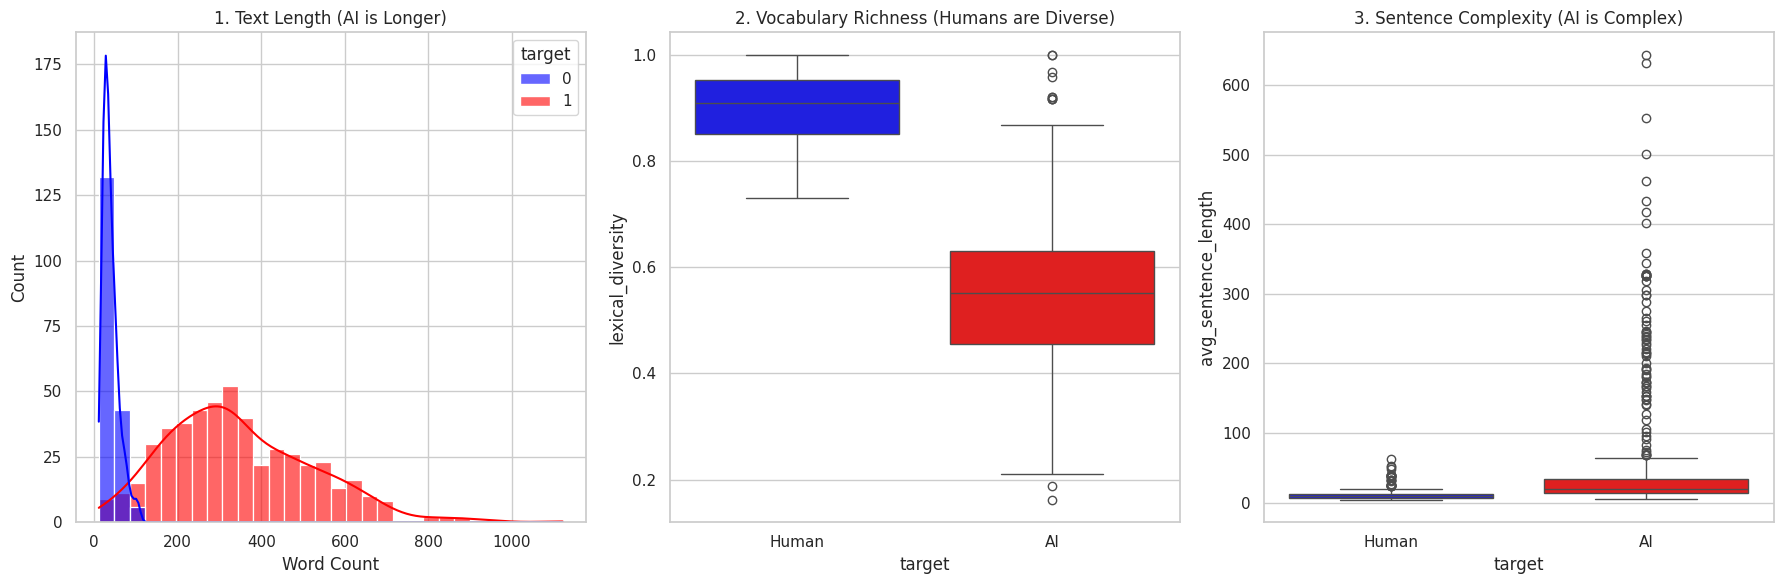

In [107]:



#  3 subplots (axes) side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 2. Define Colors (Blue for Human, Red for AI)
colors = {0: "blue", 1: "red"}

# --- Plot 1: Word Count ---
sns.histplot(data=data_sorted, x='word_count', hue='target', kde=True,
             palette=colors, bins=30, ax=axes[0], alpha=0.6)
axes[0].set_title("1. Text Length (AI is Longer)")
axes[0].set_xlabel("Word Count")

# --- Plot 2: Lexical Diversity ---
sns.boxplot(data=data_sorted, x='target', y='lexical_diversity',
            palette=colors, hue='target', legend=False, ax=axes[1])
axes[1].set_title("2. Vocabulary Richness (Humans are Diverse)")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Human', 'AI'])

# --- Plot 3: Sentence Length ---
sns.boxplot(data=data_sorted, x='target', y='avg_sentence_length',
            palette=colors, hue='target', legend=False, ax=axes[2])
axes[2].set_title("3. Sentence Complexity (AI is Complex)")
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Human', 'AI'])

# 3. Show the final image
plt.tight_layout()
plt.show()